In [ ]:
!pip install -qU langchain langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.0/572.0 kB 22.4 MB/s eta 0:00:00


In [ ]:
! pip install -qU langchain_groq

In [ ]:
from langchain_groq import ChatGroq
import os
from google.colab import userdata
os.environ["GROQ_API_KEY"]=userdata.get('GROQ_API_KEY')
os.environ["GOOGLE_API_KEY"]=userdata.get('GOOGLE_API_KEY')



In [ ]:
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0, max_tokens=200)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.4', 'langchain': '1.4.2'}}, client=<groq.resources.chat.completions.Completions object at 0x7f290e338cd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7f290e3396d0>, model_name='qwen/qwen3.8-27b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), max_tokens=200)

#Step 1: Define Schema

In [ ]:
from typing import TypedDict

class graph_schema(TypedDict):
  name:str
  message:str

#Step 2: Create The Node Fuctions

In [ ]:
def welcome(schema:graph_schema)->graph_schema:
  curr_name=schema['name']
  curr_message=schema['message']

  response = llm.invoke(f"My name is{curr_name}.{curr_message}").content
  schema['message']=f"Your message was {curr_message}.Here's my response : {response}"

  return schema

# Step 3: Create State Graph

In [ ]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(graph_schema)

#Adding Nodes
graph.add_node("welcome", welcome)

#Adding Edges
graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

#Step 4: Compile The Graph

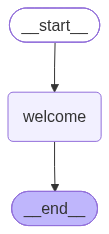

In [ ]:
from IPython.display import Image,display

first_graph=graph.compile()

Image(first_graph.get_graph().draw_mermaid_png())

#Step 5: Run The Graph

In [ ]:
first_graph.invoke({"name":"Ansh","message":"How are you?"})

{'name': 'Ansh',
 'message': "Your message was How are you?.Here's my response : Hello Ansh! I'm doing well, thank you for asking. How are you doing today?"}